<a href="https://colab.research.google.com/github/ZeroToH3ro/Predictive-Model-Advance/blob/main/Predictive_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import warnings

# Keep notebook output clean.
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.simplefilter("ignore")

import numpy as np

# Suppress NumPy floating-point warnings (e.g., divide-by-zero) that can appear during modeling.
np.seterr(all="ignore")

import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from model_utils import FiniteClipper
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis


In [2]:
def optimize_threshold(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    finite_mask = np.isfinite(thresholds)
    if finite_mask.any():
        thresholds = thresholds[finite_mask]
        fpr = fpr[finite_mask]
        tpr = tpr[finite_mask]
    else:
        return 0.5, fpr, tpr

    youden = tpr - fpr
    best_idx = np.argmax(youden)
    return thresholds[best_idx], fpr, tpr


def plot_roc_curve(fpr, tpr, auc_score, label):
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=3, label=f"{label} (AUC = {auc_score:.2f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=2)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
def bootstrap_sensitivity_analysis(
    results,
    n_bootstraps=1000,
    random_state=42,
    label="",
    save_path=None,
):
    """
    Bootstrap sensitivity analysis for all trained models.
    
    Resamples the test set `n_bootstraps` times and computes
    Accuracy, Precision, Recall, F1, and AUC on each resample.
    Reports mean, std, and 95 % confidence intervals.
    Saves an Excel summary and prints results.
    """
    import os
    import numpy as np
    import pandas as pd
    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score,
    )

    model_results = results.get("models", {})
    X_test = results["X_test"]
    y_test = results["y_test"]
    out_path = save_path or results.get("save_path", os.getcwd())
    os.makedirs(out_path, exist_ok=True)

    rng = np.random.RandomState(random_state)
    n_test = len(y_test)

    summary_rows = []

    for model_name, info in model_results.items():
        model = (info or {}).get("model")
        if model is None:
            print(f"{model_name}: model unavailable; skipping bootstrap.")
            continue

        metrics = {
            "Accuracy": [],
            "Precision": [],
            "Recall": [],
            "F1_Score": [],
            "AUC_Score": [],
        }

        skipped = 0
        for _ in range(n_bootstraps):
            idx = rng.choice(n_test, size=n_test, replace=True)
            X_boot = X_test[idx]
            y_boot = y_test[idx]

            # Need both classes for AUC
            if len(np.unique(y_boot)) < 2:
                skipped += 1
                continue

            try:
                y_proba = model.predict_proba(X_boot)[:, 1]
            except Exception:
                skipped += 1
                continue

            threshold, _, _ = optimize_threshold(y_boot, y_proba)
            y_pred = (y_proba >= threshold).astype(int)

            metrics["Accuracy"].append(accuracy_score(y_boot, y_pred))
            metrics["Precision"].append(precision_score(y_boot, y_pred, zero_division=0))
            metrics["Recall"].append(recall_score(y_boot, y_pred, zero_division=0))
            metrics["F1_Score"].append(f1_score(y_boot, y_pred, zero_division=0))
            metrics["AUC_Score"].append(roc_auc_score(y_boot, y_proba))

        if not metrics["Accuracy"]:
            print(f"{model_name}: all bootstrap iterations failed.")
            continue

        print(f"\n=== Bootstrap Sensitivity Analysis: {model_name} ===")
        print(f"    Iterations: {n_bootstraps}  |  Skipped: {skipped}")
        for m_name, values in metrics.items():
            arr = np.array(values)
            mean = np.mean(arr)
            std  = np.std(arr)
            lo   = np.percentile(arr, 2.5)
            hi   = np.percentile(arr, 97.5)
            print(f"    {m_name:12s}  mean={mean:.4f}  std={std:.4f}  "
                  f"95% CI=[{lo:.4f}, {hi:.4f}]")
            summary_rows.append({
                "Model": model_name,
                "Metric": m_name,
                "Mean": round(mean, 4),
                "Std": round(std, 4),
                "CI_Lower_2.5%": round(lo, 4),
                "CI_Upper_97.5%": round(hi, 4),
                "N_Bootstraps": n_bootstraps - skipped,
            })

    if summary_rows:
        df = pd.DataFrame(summary_rows)
        xlsx = os.path.join(out_path, f"bootstrap_sensitivity_{label}.xlsx")
        df.to_excel(xlsx, index=False)
        print(f"\nBootstrap results saved to {xlsx}")
    else:
        print("\nNo bootstrap results to save.")


In [3]:
def train_and_evaluate_models(X, y, seq_df, feature_names, label="", save_path=None, include_xgboost=True):
    try:
        from xgboost import XGBClassifier
        has_xgb = True
    except ImportError:
        has_xgb = False
        if include_xgboost:
            print("xgboost not installed; skipping XGBoost model.")

    if save_path is None:
        save_path = os.path.join(os.getcwd(), "ml_results")
    os.makedirs(save_path, exist_ok=True)

    print(f"Label: {label}")
    print("Class distribution:", pd.Series(y).value_counts().to_dict())

    indices = np.arange(len(y))
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y, indices, test_size=0.4, random_state=42, stratify=y
    )

    base_steps = [
        ("var", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("finite", FiniteClipper()),
    ]

    models = [
        {
            "name": "SVM",
            "estimator": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42),
            "param_grid": {
                "model__C": [0.1, 1, 10],
                "model__gamma": ["scale", 0.1, 0.01],
            },
            "extra_steps": [("pca", PCA(n_components=0.95, svd_solver="full", random_state=42))],
        },
        {
            "name": "Elastic Net",
            "estimator": LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                max_iter=5000,
                class_weight="balanced",
            ),
            "param_grid": {
                "model__C": [0.01, 0.1, 1, 10],
                "model__l1_ratio": [0.1, 0.5, 0.9],
            },
        },
        {
            "name": "Random Forest",
            "estimator": RandomForestClassifier(random_state=42, class_weight="balanced"),
            "param_grid": {
                "model__n_estimators": [300, 500],
                "model__max_depth": [None, 20],
                "model__min_samples_leaf": [1, 2],
            },
        },
        {
            "name": "GBM",
            "estimator": GradientBoostingClassifier(random_state=42),
            "param_grid": {
                "model__n_estimators": [200, 400],
                "model__learning_rate": [0.05, 0.1],
                "model__max_depth": [2, 3],
            },
        },
        {
            "name": "Decision Tree",
            "estimator": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
            "param_grid": {
                "model__max_depth": [3, 5, None],
                "model__min_samples_leaf": [1, 2],
            },
        },
        {
            "name": "FDA",
            "estimator": QuadraticDiscriminantAnalysis(),
            "param_grid": {
                "model__reg_param": [0.0, 0.1, 0.5],
            },
        },
        {
            "name": "KNN",
            "estimator": KNeighborsClassifier(),
            "param_grid": {
                "model__n_neighbors": [3, 5, 7],
                "model__weights": ["uniform", "distance"],
            },
        },
        {
            "name": "Logistic Regression",
            "estimator": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42),
            "param_grid": {
                "model__C": [0.01, 0.1, 1, 10],
            },
        },
        {
            "name": "Naive Bayesian",
            "estimator": GaussianNB(),
            "param_grid": {
                "model__var_smoothing": [1e-9, 1e-8, 1e-7],
            },
        },
        {
            "name": "Neural Network",
            "estimator": MLPClassifier(max_iter=1000, random_state=42),
            "param_grid": {
                "model__hidden_layer_sizes": [(50,), (100,)],
                "model__alpha": [0.0001, 0.001, 0.01],
            },
        },
        {
            "name": "Voting Classifier",
            "estimator": VotingClassifier(
                estimators=[
                    ("lr", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)),
                    ("rf", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)),
                    ("gbm", GradientBoostingClassifier(n_estimators=100, random_state=42))
                ],
                voting="soft"
            ),
            "param_grid": {},
        },
        {
            "name": "Stacking Classifier",
            "estimator": StackingClassifier(
                estimators=[
                    ("lr", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)),
                    ("rf", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)),
                    ("gbm", GradientBoostingClassifier(n_estimators=100, random_state=42))
                ],
                final_estimator=LogisticRegression(max_iter=1000)
            ),
            "param_grid": {},
        }
    ]


    if include_xgboost and has_xgb:
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = float(neg) / pos if pos > 0 else 1.0
        models.append({
            "name": "XGBoost",
            "estimator": XGBClassifier(
                random_state=42,
                eval_metric="logloss",
                tree_method="hist",
                scale_pos_weight=scale_pos_weight,
            ),
            "param_grid": {
                "model__n_estimators": [300, 500],
                "model__learning_rate": [0.05, 0.1],
                "model__max_depth": [3, 5],
                "model__subsample": [0.8, 1.0],
                "model__colsample_bytree": [0.8, 1.0],
            },
        })

    metrics = []
    preds_df = pd.DataFrame({
        "Accession number": seq_df.iloc[idx_test]["Accession number"].values,
        "True_Label": y_test,
    })
    model_results = {}

    for cfg in models:
        print(f"\nTraining {cfg['name']}...")
        steps = list(base_steps)
        if cfg.get("extra_steps"):
            steps.extend(cfg["extra_steps"])
        steps.append(("model", cfg["estimator"]))

        pipeline = Pipeline(steps=steps)
        search = GridSearchCV(pipeline, cfg["param_grid"], scoring="roc_auc", cv=5, n_jobs=1)
        search.fit(X_train, y_train)

        model = search.best_estimator_
        print(f"Best params for {cfg['name']}: {search.best_params_}")
        print(f"Best CV ROC-AUC: {search.best_score_:.4f}")

        y_proba = model.predict_proba(X_test)[:, 1]
        threshold, fpr, tpr = optimize_threshold(y_test, y_proba)
        y_pred = (y_proba >= threshold).astype(int)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        auc_score = roc_auc_score(y_test, y_proba)

        metrics.append({
            "Model": cfg["name"],
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1_Score": f1,
            "AUC_Score": auc_score,
            "Threshold": threshold,
        })

        col_base = cfg["name"].replace(" ", "_")
        preds_df[f"Pred_{col_base}"] = y_pred
        preds_df[f"Prob_{col_base}"] = np.round(y_proba * 100, 2)

        model_results[cfg["name"]] = {
            "model": model,
            "threshold": threshold,
            "metrics": metrics[-1],
            "fpr": fpr,
            "tpr": tpr,
            "y_pred": y_pred,
            "y_proba": y_proba,
        }

        if cfg["name"] == "SVM":
            print(f"Optimal threshold (Youden): {threshold:.4f}")
            print(f"Accuracy: {accuracy:.4f}")
            print(f"Precision: {precision:.4f}")
            print(f"Recall: {recall:.4f}")
            print(f"F1 Score: {f1:.4f}")
            print(f"AUC Score: {auc_score:.4f}")
            print("Confusion matrix:")
            print(confusion_matrix(y_test, y_pred))
            plot_roc_curve(fpr, tpr, auc_score, label=label or cfg["name"])

    label_map = {0: "Success", 1: "Failure"}
    preds_df["True_Label"] = preds_df["True_Label"].map(label_map)
    for col in preds_df.columns:
        if col.startswith("Pred_"):
            preds_df[col] = preds_df[col].map({0: "Success", 1: "Failure"})

    preds_path = os.path.join(save_path, f"ensemble_predictions_{label}.xlsx")
    preds_df.to_excel(preds_path, index=False)

    metrics_df = pd.DataFrame(metrics)
    metrics_path = os.path.join(save_path, f"model_metrics_{label}.xlsx")
    metrics_df.to_excel(metrics_path, index=False)

    return {
        "models": model_results,
        "metrics": metrics_df,
        "predictions": preds_df,
        "X_train": X_train,
        "X_test": X_test,
        "y_test": y_test,
        "feature_names": feature_names,
        "save_path": save_path,
    }


In [4]:
def explain_with_shap(model, X_train, X_test, feature_names, max_background=50, max_samples=20, top_n_features=30, save_path=None, label=""):
    try:
        import shap
    except ImportError:
        print("SHAP not installed; skipping explainability.")
        return

    rng = np.random.RandomState(42)
    bg_size = min(max_background, len(X_train))
    sample_size = min(max_samples, len(X_test))

    background = X_train[rng.choice(len(X_train), size=bg_size, replace=False)]
    samples = X_test[:sample_size]

    print("Running SHAP on a small sample for explainability...")
    explainer = shap.KernelExplainer(model.predict_proba, background)
    shap_values = explainer.shap_values(samples, nsamples=100)

    if isinstance(shap_values, list):
        shap_matrix = shap_values[1] if len(shap_values) > 1 else shap_values[0]
    else:
        shap_matrix = shap_values
        if shap_matrix.ndim == 3:
            shap_matrix = shap_matrix[:, :, 1] if shap_matrix.shape[-1] > 1 else shap_matrix[:, :, 0]

    # Some SHAP versions include a final bias column; drop if present.
    if shap_matrix.shape[1] == samples.shape[1] + 1:
        shap_matrix = shap_matrix[:, :-1]

    if shap_matrix.shape[0] != samples.shape[0] and shap_matrix.shape[1] == samples.shape[0]:
        shap_matrix = shap_matrix.T

    if shap_matrix.shape[1] != samples.shape[1]:
        print("SHAP output shape does not match input features; skipping plot.")
        return

    if len(feature_names) != samples.shape[1]:
        feature_names = [f"feature_{i}" for i in range(samples.shape[1])]

    safe_label = (label or "run").replace(" ", "_")

    if save_path:
        os.makedirs(save_path, exist_ok=True)
        shap_df = pd.DataFrame(shap_matrix, columns=feature_names)
        shap_df.to_excel(os.path.join(save_path, f"shap_values_{safe_label}.xlsx"), index=False)

    mean_abs_shap = np.abs(shap_matrix).mean(axis=0)
    top_n = min(int(top_n_features), len(feature_names)) if top_n_features else len(feature_names)
    top_idx = np.argsort(mean_abs_shap)[::-1][:top_n]

    shap_plot = shap_matrix[:, top_idx]
    samples_plot = samples[:, top_idx]
    plot_names = [feature_names[i] for i in top_idx]

    shap.summary_plot(shap_plot, samples_plot, feature_names=plot_names, show=False)
    if save_path:
        plt.tight_layout()
        plt.savefig(os.path.join(save_path, f"shap_summary_{safe_label}.png"), dpi=200)
        plt.show()
        plt.close()
    else:
        plt.show()

    plt.figure(figsize=(10, 6))
    plt.imshow(shap_plot, aspect="auto", cmap="coolwarm")
    plt.title("SHAP heatmap (top features)")
    plt.xlabel("Top features")
    plt.ylabel("Samples")
    if len(plot_names) <= 30:
        plt.xticks(ticks=np.arange(len(plot_names)), labels=plot_names, rotation=45, ha="right")
    else:
        plt.xticks([])
    plt.colorbar(label="SHAP value")
    plt.tight_layout()
    if save_path:
        plt.savefig(os.path.join(save_path, f"shap_heatmap_{safe_label}.png"), dpi=200)
        plt.show()
        plt.close()
    else:
        plt.show()


In [5]:
def plot_model_comparisons(results, label="", save_path=None):
    metrics_df = results.get("metrics")
    model_results = results.get("models", {}) if results else {}

    if metrics_df is None or len(metrics_df) == 0:
        print("No metrics available to plot.")
        return

    metric_cols = [
        "AUC_Score",
        "F1_Score",
        "Accuracy",
        "Precision",
        "Recall",
    ]
    metric_cols = [m for m in metric_cols if m in metrics_df.columns]
    safe_label = (label or "run").replace(" ", "_")
    chart_num = 1

    if metric_cols:
        x = np.arange(len(metrics_df))
        width = 0.8 / len(metric_cols)
        plt.figure(figsize=(12, 6))
        for i, metric in enumerate(metric_cols):
            plt.bar(x + i * width, metrics_df[metric], width=width, label=metric)
        plt.xticks(x + width * (len(metric_cols) - 1) / 2, metrics_df["Model"], rotation=30, ha="right")
        plt.ylabel("Score")
        title = f"Chart {chart_num}: Model performance comparison"
        if label:
            title = f"Chart {chart_num}: Model performance comparison ({label})"
        plt.title(title)
        plt.ylim(0, 1)
        plt.legend()
        plt.tight_layout()
        if save_path:
            plt.savefig(os.path.join(save_path, f"model_metric_comparison_{safe_label}.png"), dpi=200)
        plt.show()
        chart_num += 1
    else:
        print("No metric columns found for plotting.")

    plt.figure(figsize=(8, 6))
    roc_plotted = False
    for name, res in model_results.items():
        fpr, tpr = res.get("fpr"), res.get("tpr")
        if fpr is None or tpr is None:
            continue
        auc_val = None
        if isinstance(res.get("metrics"), dict):
            auc_val = res["metrics"].get("AUC_Score")
        label_str = f"{name} (AUC = {auc_val:.2f})" if auc_val is not None else name
        plt.plot(fpr, tpr, linewidth=2, label=label_str)
        roc_plotted = True

    if roc_plotted:
        plt.plot([0, 1], [0, 1], "k--", linewidth=1)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        title = f"Chart {chart_num}: ROC comparison"
        if label:
            title = f"Chart {chart_num}: ROC comparison ({label})"
        plt.title(title)
        plt.legend()
        plt.tight_layout()
        if save_path:
            plt.savefig(os.path.join(save_path, f"roc_comparison_{safe_label}.png"), dpi=200)
        plt.show()
    else:
        plt.close()
        print("No ROC data available to plot.")


In [6]:
def plot_learning_curve(model, X, y, label="", save_path=None, cv=5):
    from sklearn.model_selection import learning_curve, StratifiedKFold

    cv_splitter = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    train_sizes = np.linspace(0.1, 1.0, 5)

    sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        train_sizes=train_sizes,
        cv=cv_splitter,
        scoring="roc_auc",
        n_jobs=1,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(sizes, train_mean, "o-", label="Train AUC")
    plt.plot(sizes, val_mean, "o-", label="CV AUC")
    plt.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
    plt.xlabel("Training set size")
    plt.ylabel("ROC-AUC")
    plt.title(f"Learning curve ({label})" if label else "Learning curve")
    plt.legend()
    plt.tight_layout()

    safe_label = (label or "run").replace(" ", "_")
    if save_path:
        plt.savefig(os.path.join(save_path, f"learning_curve_{safe_label}.png"), dpi=200)
    plt.show()


def get_best_model_info(results, metric="AUC_Score"):
    metrics_df = results.get("metrics")
    model_results = results.get("models", {})

    if metrics_df is None or metrics_df.empty:
        raise ValueError("No metrics found in results.")

    best_row = metrics_df.sort_values(metric, ascending=False).iloc[0]
    best_name = best_row["Model"]
    best_result = model_results[best_name]
    return best_name, best_result


def run_learning_curve_and_shap(results, X, y, label="", save_path=None):
    best_name, best_result = get_best_model_info(results)
    model_label = f"{label}_{best_name}" if label else best_name
    print(f"Best model for {label}: {best_name}")

    print(f"\n=== {best_name}: Learning Curve ===")
    plot_learning_curve(best_result["model"], X, y, label=model_label, save_path=save_path)

    print(f"\n=== {best_name}: SHAP ===")
    explain_with_shap(
        best_result["model"],
        results["X_train"],
        results["X_test"],
        results["feature_names"],
        save_path=save_path,
        label=model_label,
    )


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import pandas as pd
import os
from datetime import datetime

def sequence_to_features(seq, seq_type='dna'):
    if pd.isna(seq):
        return []
    seq = str(seq).upper().strip()
    if seq_type == 'dna':
        mapping = {'A':1, 'C':2, 'G':3, 'T':4}
    else:
        aa_list = "ACDEFGHIKLMNPQRSTVWY"
        mapping = {aa: i+1 for i, aa in enumerate(aa_list)}
    return [mapping.get(char, 0) for char in seq]

def _normalize_column_name(name):
    return " ".join(str(name).replace("_", " ").split()).strip().lower()


def _resolve_columns(data, expected_columns):
    normalized_lookup = {_normalize_column_name(col): col for col in data.columns}
    resolved_columns = []
    missing_columns = []

    for col in expected_columns:
        resolved = normalized_lookup.get(_normalize_column_name(col))
        if resolved is None:
            missing_columns.append(col)
        else:
            resolved_columns.append(resolved)

    if missing_columns:
        raise ValueError(
            f"Missing columns in data: {missing_columns}. Available columns: {list(data.columns)}"
        )

    return resolved_columns


def _load_sequence_data(data_path):
    preview = pd.read_excel(data_path, header=None, nrows=10)
    header_row = None

    for idx, row in preview.iterrows():
        normalized = {_normalize_column_name(value) for value in row.tolist() if pd.notna(value)}
        if {"accession number", "respond"}.issubset(normalized):
            header_row = idx
            break

    if header_row is None:
        raise ValueError("Could not detect the header row in the Excel file.")

    return pd.read_excel(data_path, header=header_row)


def prepare_data_amino(data_path):
    # Load dataset
    data = _load_sequence_data(data_path)

    # Use the 'Full aa' column for training
    amino_columns = _resolve_columns(data, ['Full aa'])
    col_name = amino_columns[0]

    # Convert each full amino acid sequence to numerical features
    X_raw = data[col_name].apply(lambda seq: sequence_to_features(seq, seq_type='aa')).tolist()

    # Pad the sequences to make them the same length
    max_seq_len = max((len(seq) for seq in X_raw if isinstance(seq, list)), default=1)
    if max_seq_len == 0:
        max_seq_len = 1

    padded_X = []
    for seq in X_raw:
        if not isinstance(seq, list):
            seq = []
        padded_seq = pad_sequences([seq], maxlen=max_seq_len, padding='post', value=0)[0]
        padded_X.append(padded_seq)

    X = np.array(padded_X)  # shape: (n_samples, max_seq_len)

    # Target vector y from "Respond"
    y = data['Respond'].map({'Yes': 1, 'No': 0, 'SVR': 0, 'Non SVR': 1, 'SVR ': 0, 'Non SVR ': 1}).values
    # Clean up NaNs
    valid_idx = ~np.isnan(y)
    X = X[valid_idx]
    y = y[valid_idx]
    data = data[valid_idx].reset_index(drop=True)

    # Add a check for unique values in y
    unique_classes = np.unique(y)
    if len(unique_classes) < 2:
        raise ValueError(f"Target variable 'Respond' has only {len(unique_classes)} unique class(es): {unique_classes}. "
                        f"At least two classes are needed for classification.")

    return X, y, data

def prepare_data_nucleotide(data_path):
    # Load dataset
    data = _load_sequence_data(data_path)

    # Use the 'Full Nu' column for training
    nucleotide_columns = _resolve_columns(data, ['Full Nu'])
    col_name = nucleotide_columns[0]
    print("Resolved nucleotide column:", col_name)

    # Convert each full nucleotide sequence to numerical features
    X_raw = data[col_name].apply(lambda seq: sequence_to_features(seq, seq_type='dna')).tolist()

    # Pad the sequences to make them the same length
    max_seq_len = max((len(seq) for seq in X_raw if isinstance(seq, list)), default=1)
    if max_seq_len == 0:
        max_seq_len = 1

    padded_X = []
    for seq in X_raw:
        if not isinstance(seq, list):
            seq = []
        padded_seq = pad_sequences([seq], maxlen=max_seq_len, padding='post', value=0)[0]
        padded_X.append(padded_seq)

    X = np.array(padded_X)  # shape: (n_samples, max_seq_len)

    # Target vector y from "Respond"
    y = data['Respond'].map({'Yes': 1, 'No': 0, 'SVR': 0, 'Non SVR': 1, 'SVR ': 0, 'Non SVR ': 1}).values
    # Clean up NaNs
    valid_idx = ~np.isnan(y)
    X = X[valid_idx]
    y = y[valid_idx]
    data = data[valid_idx].reset_index(drop=True)

    # Add a check for unique values in y
    unique_classes = np.unique(y)
    if len(unique_classes) < 2:
        raise ValueError(f"Target variable 'Respond' has only {len(unique_classes)} unique class(es): {unique_classes}. "
                         f"At least two classes are needed for classification.")

    return X, y, data

data_path = "data/full_gene_and_3_regions.xlsx"

# --- 1. Train on Amino Acid ---
print("=== Training on Amino Acid (Aa) ===")
X_aa, y_aa, data_aa = prepare_data_amino(data_path)
feature_names_aa = [f"Feature_Aa_{i}" for i in range(X_aa.shape[1])]
run_dir_aa = os.path.join("outputs", "Experiment_Aa_" + datetime.now().strftime("%Y%m%d_%H%M%S"))

results_aa = train_and_evaluate_models(
    X_aa,
    y_aa,
    seq_df=data_aa,
    feature_names=feature_names_aa,
    label="Amino_Acid",
    save_path=run_dir_aa,
)

plot_model_comparisons(
    results_aa,
    label="Amino_Acid",
    save_path=run_dir_aa,
)

run_learning_curve_and_shap(
    results_aa,
    X_aa,
    y_aa,
    label="Amino_Acid",
    save_path=run_dir_aa,
)

# --- 2. Train on Nucleotide ---
print("\n=== Training on Nucleotide (Nu) ===")
X_nu, y_nu, data_nu = prepare_data_nucleotide(data_path)
feature_names_nu = [f"Feature_Nu_{i}" for i in range(X_nu.shape[1])]
run_dir_nu = os.path.join("outputs", "Experiment_Nu_" + datetime.now().strftime("%Y%m%d_%H%M%S"))

results_nu = train_and_evaluate_models(
    X_nu,
    y_nu,
    seq_df=data_nu,
    feature_names=feature_names_nu,
    label="Nucleotide",
    save_path=run_dir_nu,
)

plot_model_comparisons(
    results_nu,
    label="Nucleotide",
    save_path=run_dir_nu,
)

run_learning_curve_and_shap(
    results_nu,
    X_nu,
    y_nu,
    label="Nucleotide",
    save_path=run_dir_nu,
)

# --- Bootstrap Sensitivity Analysis (Amino_Acid) ---
print("\n=== Bootstrap Sensitivity Analysis (Amino_Acid) ===")
bootstrap_sensitivity_analysis(
    results_aa,
    n_bootstraps=1000,
    label="Amino_Acid",
    save_path=run_dir_aa,
)

# --- Bootstrap Sensitivity Analysis (Nucleotide) ---
print("\n=== Bootstrap Sensitivity Analysis (Nucleotide) ===")
bootstrap_sensitivity_analysis(
    results_nu,
    n_bootstraps=1000,
    label="Nucleotide",
    save_path=run_dir_nu,
)


In [ ]:
def plot_tsne_embedding(
    X,
    labels=None,
    text_labels=None,
    label_name="subtype",
    perplexity=None,
    max_iter=1000,
    pca_components=50,
    random_state=42,
    annotate=True,
    annotate_max_points=300,
    annotate_fontsize=8,
    draw_group_outline=False,
    outline_kind="ellipse",
    outline_n_std=2.0,
    outline_expand=1.15,
    outline_linewidth=2.0,
    outline_alpha=1.0,
    outline_min_points=3,
    circle_quantile=0.9,
    point_size=70,
    point_alpha=0.85,
    save_path=None,
    label="",
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.patches import Circle, Ellipse
    import seaborn as sns
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler

    X = np.asarray(X)
    if X.ndim != 2:
        raise ValueError("X must be a 2D array of shape (n_samples, n_features).")

    n_samples = X.shape[0]
    if n_samples < 3:
        raise ValueError("t-SNE requires at least 3 samples.")

    labels_series = None
    if labels is not None:
        labels_series = pd.Series(labels).astype(str)
        if len(labels_series) != n_samples:
            raise ValueError("labels must have the same length as X.")

    text_series = None
    if text_labels is not None:
        text_series = pd.Series(text_labels).astype(str)
        if len(text_series) != n_samples:
            raise ValueError("text_labels must have the same length as X.")
    elif labels_series is not None:
        text_series = labels_series

    X_scaled = StandardScaler().fit_transform(X)
    X_for_tsne = X_scaled
    if pca_components and X_scaled.shape[1] > pca_components:
        n_comp = int(min(pca_components, X_scaled.shape[0] - 1, X_scaled.shape[1]))
        if n_comp >= 2:
            X_for_tsne = PCA(n_components=n_comp, random_state=random_state).fit_transform(X_scaled)

    if perplexity is None:
        perplexity = min(30, max(5, (n_samples - 1) // 3))
    perplexity = float(min(perplexity, n_samples - 1))

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        max_iter=max_iter,
        random_state=random_state,
    )
    emb = tsne.fit_transform(X_for_tsne)

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(10, 8))

    if labels_series is None:
        ax.scatter(
            emb[:, 0],
            emb[:, 1],
            s=point_size,
            alpha=point_alpha,
            color=sns.color_palette("deep", 1)[0],
            edgecolors="white",
            linewidths=0.5,
        )
    else:
        groups = list(pd.unique(labels_series))
        palette = sns.color_palette("Set1", n_colors=len(groups))
        color_map = dict(zip(groups, palette))
        for g in groups:
            mask = labels_series == g
            ax.scatter(
                emb[mask.values, 0],
                emb[mask.values, 1],
                s=point_size,
                alpha=point_alpha,
                color=color_map[g],
                label=g,
                edgecolors="white",
                linewidths=0.5,
            )

        if draw_group_outline:
            for g in groups:
                mask = labels_series == g
                pts = emb[mask.values]
                if pts.shape[0] < outline_min_points:
                    continue

                color = color_map.get(g, "black")
                center = pts.mean(axis=0)

                if str(outline_kind).lower() == "circle":
                    d = np.sqrt(((pts - center) ** 2).sum(axis=1))
                    radius = float(np.quantile(d, circle_quantile)) * float(outline_expand)
                    if np.isfinite(radius) and radius > 0:
                        ax.add_patch(
                            Circle(
                                xy=center,
                                radius=radius,
                                fill=False,
                                edgecolor=color,
                                linewidth=outline_linewidth,
                                alpha=outline_alpha,
                                zorder=0,
                            )
                        )
                else:
                    cov = np.cov(pts.T)
                    if not np.isfinite(cov).all():
                        continue
                    vals, vecs = np.linalg.eigh(cov)
                    order = np.argsort(vals)[::-1]
                    vals = vals[order]
                    vecs = vecs[:, order]
                    vals = np.maximum(vals, 1e-12)
                    width, height = 2.0 * float(outline_n_std) * np.sqrt(vals[:2])
                    width *= float(outline_expand)
                    height *= float(outline_expand)
                    angle = float(np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0])))
                    ax.add_patch(
                        Ellipse(
                            xy=center,
                            width=float(width),
                            height=float(height),
                            angle=angle,
                            fill=False,
                            edgecolor=color,
                            linewidth=outline_linewidth,
                            alpha=outline_alpha,
                            zorder=0,
                        )
                    )
        ax.legend(
            title=label_name,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.18),
            ncol=min(4, len(groups)),
            frameon=False,
        )

    if annotate and text_series is not None:
        if len(text_series) > annotate_max_points:
            print(
                f"Skipping point labels: n={len(text_series)} exceeds annotate_max_points={annotate_max_points}."
            )
        else:
            dx = 0.01 * (float(emb[:, 0].max()) - float(emb[:, 0].min()) or 1.0)
            dy = 0.01 * (float(emb[:, 1].max()) - float(emb[:, 1].min()) or 1.0)
            for i in range(n_samples):
                if labels_series is None:
                    txt_color = "black"
                else:
                    txt_color = color_map.get(labels_series.iloc[i], "black")
                ax.text(
                    emb[i, 0] + dx,
                    emb[i, 1] + dy,
                    text_series.iloc[i],
                    fontsize=annotate_fontsize,
                    color=txt_color,
                    alpha=0.9,
                )

    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    title = "Unsupervised clustering of training data using t-SNE dimensionality reduction."
    if label:
        title = f"{title} ({label})"
    ax.set_title(title)
    plt.tight_layout()

    if save_path:
        os.makedirs(save_path, exist_ok=True)
        safe_label = (label or "run").replace(" ", "_")
        out_path = os.path.join(save_path, f"tsne_training_data_{safe_label}.png")
        plt.savefig(out_path, dpi=200, bbox_inches="tight")

    plt.show()
    return emb

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis


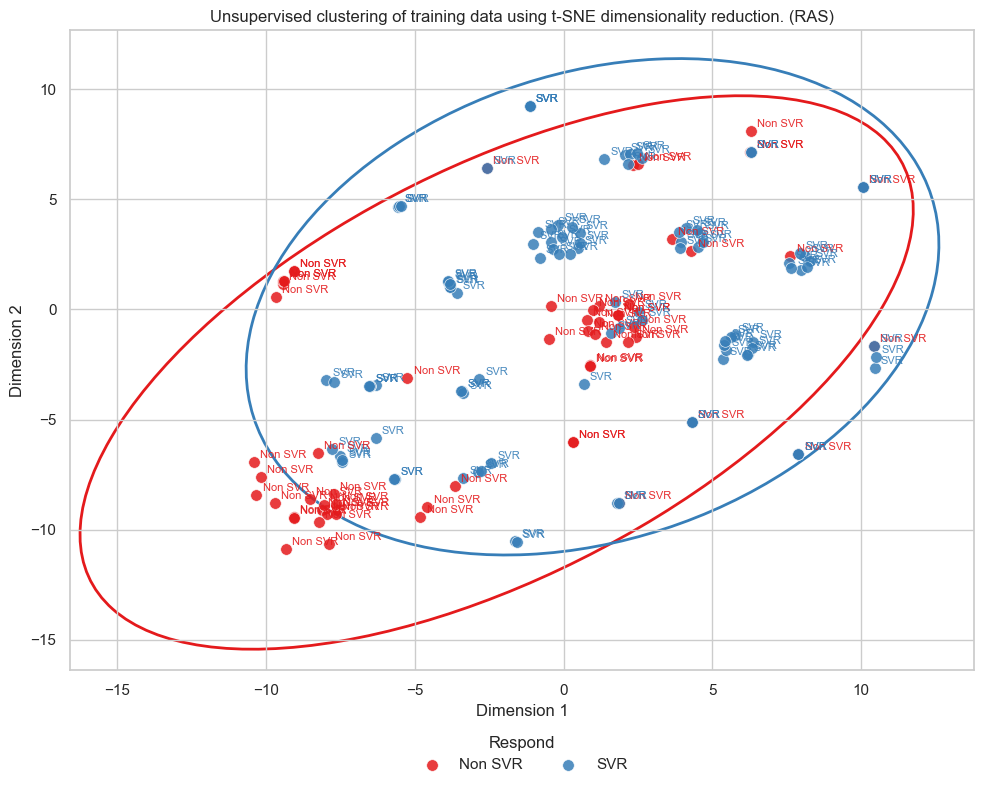

In [ ]:
# t-SNE visualization for the sequence-only training sets
tsne_runs = []

if all(name in globals() for name in ["X_aa", "data_aa", "run_dir_aa"]):
    tsne_runs.append((X_aa, data_aa, run_dir_aa, "Amino_Acid"))

if all(name in globals() for name in ["X_nu", "data_nu", "run_dir_nu"]):
    tsne_runs.append((X_nu, data_nu, run_dir_nu, "Nucleotide"))

if tsne_runs:
    for X_current, data_current, run_dir_current, label_current in tsne_runs:
        _ = plot_tsne_embedding(
            X_current,
            labels=data_current["Respond"] if "Respond" in data_current.columns else None,
            text_labels=data_current["Respond"] if "Respond" in data_current.columns else None,
            label_name="Respond",
            draw_group_outline=True,
            outline_kind="ellipse",
            save_path=run_dir_current,
            label=label_current,
        )
else:
    print("Run the amino-acid or nucleotide training cell above first.")
